In [1]:
import os, glob, math
import numpy as np
import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
from scipy.signal import butter, filtfilt

In [2]:
# --- Download and locate one URFall sequence directly from online data server (RGB frames from cam0) ---

SEQ  = "adl-01" # which sequence to pull
BASE = "https://fenix.ur.edu.pl/mkepski/ds/data" # base url of URFall data server

# download the zipped RGB frames for this sequence into the data/folder
!curl -sL {BASE}/{SEQ}-cam0-rgb.zip -o ../data/rgb.zip

# unzip those frames into data folder
!unzip -q -o ../data/rgb.zip -d ../data/{SEQ}_rgb

# collect every .png in that folder, sorted into chronological order so the motion plays in sequence
frame_paths = sorted(glob.glob(f"../data/{SEQ}_rgb/**/*.png", recursive=True))
print(f"{len(frame_paths)} frames")
print("first:", frame_paths[0] if frame_paths else "NONE — check the folder")

150 frames
first: ../data/adl-01_rgb/adl-01-cam0-rgb/adl-01-cam0-rgb-001.png


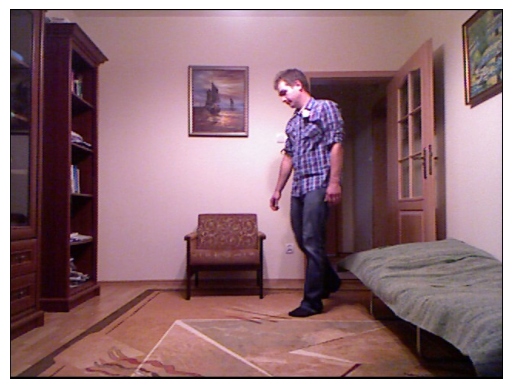

frame size: (480, 640, 3)


In [36]:
# --- Look at one frame to confirm there's a person in view ---

# read the first frame, convert to RGB for correct colors
img = cv2.cvtColor(cv2.imread(frame_paths[75]), cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")          # hide the pixel-axis ticks, just show the image
plt.show()

print("frame size:", img.shape)   # (height, width, channels)

In [37]:
# --- Run MediaPipe pose estimation on the first frame ---

mp_pose = mp.solutions.pose   # the pose model

# create a pose detector. static_image_mode=True treats each image independently
# (good for a single test frame); model_complexity=2 is the most accurate setting.
with mp_pose.Pose(static_image_mode=True, model_complexity=2) as pose:
    results = pose.process(img)   # img is already RGB from the last cell

# test if it found a person
if results.pose_landmarks:
    print("Pose detected!")
    print("number of landmarks:", len(results.pose_landmarks.landmark))
else:
    print("No pose detected — try a different frame.")

Pose detected!
number of landmarks: 33


I0000 00:00:1782859088.918889 37969676 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4 Pro
W0000 00:00:1782859088.990921 38041875 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1782859089.024842 38041877 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


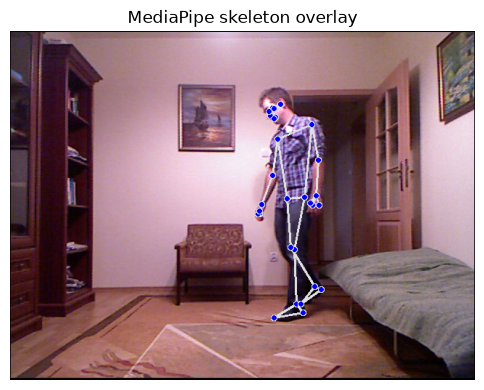

In [38]:
# --- Draw the detected skeleton on the frame for sanity-check of markerless pose estimation  ---

annotated = img.copy()   # work on a copy so the original stays clean

mp_drawing = mp.solutions.drawing_utils   # MediaPipe's helper for drawing landmarks
mp_drawing.draw_landmarks(
    annotated,
    results.pose_landmarks,            # the 33 points just found
    mp_pose.POSE_CONNECTIONS,          # which points to connect (the "bones")
)

plt.figure(figsize=(6, 8))
plt.imshow(annotated)
plt.axis("off")
plt.title("MediaPipe skeleton overlay")
plt.show()

In [ ]:
# --- Compute a joint angle from three landmarks ---

def joint_angle(a, b, c):
    """Angle (degrees) at joint b, formed by points a-b-c. Using basic math + trigonometry - 
    dot product formula. Works on 2D or 3D points."""
    a, b, c = np.array(a), np.array(b), np.array(c)
    u = a - b # bone 1: joint b -> point a
    v = c - b # bone 2: joint b -> point c
    cos = np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))
    return np.degrees(np.arccos(np.clip(cos, -1, 1)))

# MediaPipe landmark indices for the LEFT leg
HIP, KNEE, ANKLE = 23, 25, 27

lm = results.pose_landmarks.landmark   # the 33 landmarks

# get (x, y) for each joint; MediaPipe gives normalized coords (0-1)
hip   = [lm[HIP].x,   lm[HIP].y]
knee  = [lm[KNEE].x,  lm[KNEE].y]
ankle = [lm[ANKLE].x, lm[ANKLE].y]

knee_angle = joint_angle(hip, knee, ankle)
print(f"left knee angle: {knee_angle:.1f}°")

left knee angle: 169.4°


In [15]:
# --- Compute the left knee angle across every frame ---

knee_angles = []   # will hold one angle per frame

with mp_pose.Pose(static_image_mode=False, model_complexity=2) as pose:
    for path in frame_paths:
        # load frame and convert BGR -> RGB
        frame = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        res = pose.process(frame)

        if res.pose_landmarks:
            lm = res.pose_landmarks.landmark
            hip = [lm[HIP].x,   lm[HIP].y]
            knee = [lm[KNEE].x,  lm[KNEE].y]
            ankle = [lm[ANKLE].x, lm[ANKLE].y]
            knee_angles.append(joint_angle(hip, knee, ankle))
        else:
            knee_angles.append(np.nan)   # no person found -> mark as missing

knee_angles = np.array(knee_angles)

n_found = np.sum(~np.isnan(knee_angles))
print(f"got angles for {n_found} / {len(frame_paths)} frames")
print(f"range: {np.nanmin(knee_angles):.0f}° to {np.nanmax(knee_angles):.0f}°")

I0000 00:00:1782857203.220310 37969676 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4 Pro
W0000 00:00:1782857203.295411 38009803 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1782857203.349595 38009802 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


got angles for 136 / 150 frames
range: 22° to 180°


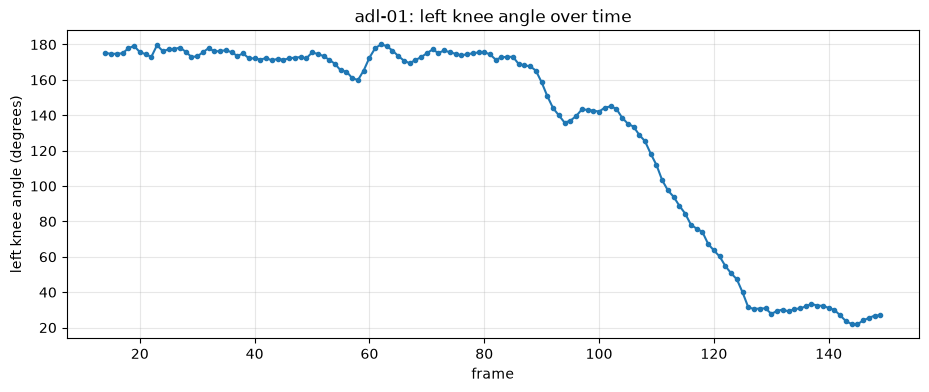

In [40]:
# --- Plot the left knee angle over time ---

plt.figure(figsize=(11, 4))
plt.plot(knee_angles, marker=".")          # one point per frame, connected
plt.xlabel("frame")
plt.ylabel("left knee angle (degrees)")
plt.title("adl-01: left knee angle over time")
plt.grid(True, alpha=0.3)
plt.show()

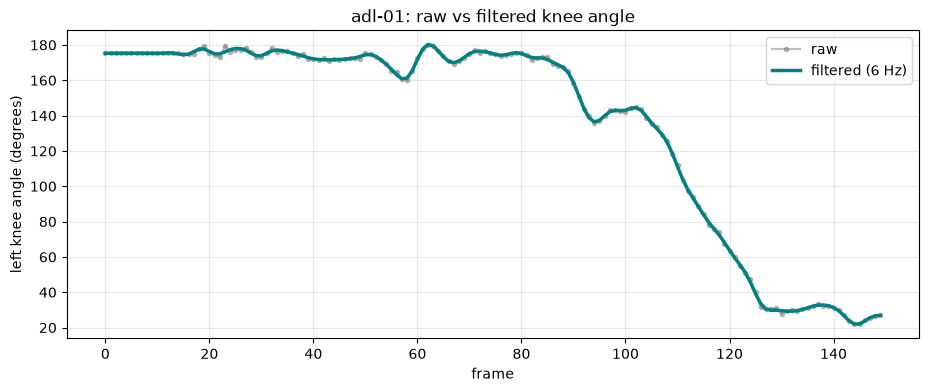

In [41]:
# --- Low-pass filter the knee-angle signal ---

# 1. Fill the NaN gaps by linear interpolation, so the filter has a continuous signal.
def interp_nans(y):
    y = y.copy()
    n = np.arange(len(y))
    good = ~np.isnan(y) # which frames have real values
    y[~good] = np.interp(n[~good], n[good], y[good]) # fill gaps from neighbors
    return y

# 2. Butterworth low-pass filter.
def lowpass(signal, cutoff=6.0, fs=30.0, order=4):
    b, a = butter(order, cutoff / (fs / 2), btype="low") # design the filter
    return filtfilt(b, a, signal) # apply it (zero phase lag)

knee_filled = interp_nans(knee_angles)
knee_filtered = lowpass(knee_filled, cutoff=6.0, fs=30.0)

# 3. Plot raw vs filtered, overlaid.
plt.figure(figsize=(11, 4))
plt.plot(knee_filled,   color="gray", alpha=0.5, marker=".", label="raw")
plt.plot(knee_filtered, color="teal", linewidth=2.5,        label="filtered (6 Hz)")
plt.xlabel("frame")
plt.ylabel("left knee angle (degrees)")
plt.title("adl-01: raw vs filtered knee angle")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [42]:
# --- Download the depth frames for the same sequence (cam0) ---
!curl -sL {BASE}/{SEQ}-cam0-d.zip -o ../data/depth.zip
!unzip -q -o ../data/depth.zip -d ../data/{SEQ}_depth

depth_paths = sorted(glob.glob(f"../data/{SEQ}_depth/**/*.png", recursive=True))
print(f"{len(depth_paths)} depth frames")
print("first:", depth_paths[0] if depth_paths else "NONE")

150 depth frames
first: ../data/adl-01_depth/adl-01-cam0-d/adl-01-cam0-d-001.png


dtype: uint16  shape: (480, 640)  max raw: 64159


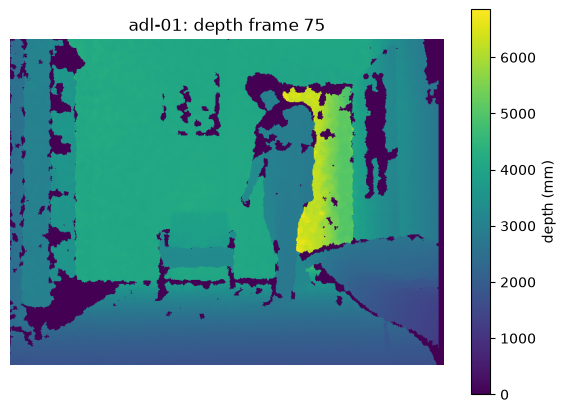

In [61]:
# --- Load and decode one depth frame ---

# IMREAD_UNCHANGED keeps the full 16-bit values (a normal imread would crush them down to 8-bit and destroy the distances).
raw = cv2.imread(depth_paths[75], cv2.IMREAD_UNCHANGED)
print("dtype:", raw.dtype, " shape:", raw.shape, " max raw:", raw.max())

# rescale the raw 16-bit values into real distance in millimeters.
# C is URFall's per-camera scale constant: 7000 for ADL cam0.
C = 7000
depth_mm = C * raw.astype(np.float32) / 65535.0

plt.figure(figsize=(7, 5))
plt.imshow(depth_mm, cmap="viridis") # color = distance
plt.colorbar(label="depth (mm)")
plt.title("adl-01: depth frame 75")
plt.axis("off")
plt.show()

I0000 00:00:1782942128.172910 37969676 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4 Pro
W0000 00:00:1782942128.270001 38752003 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1782942128.335199 38752001 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


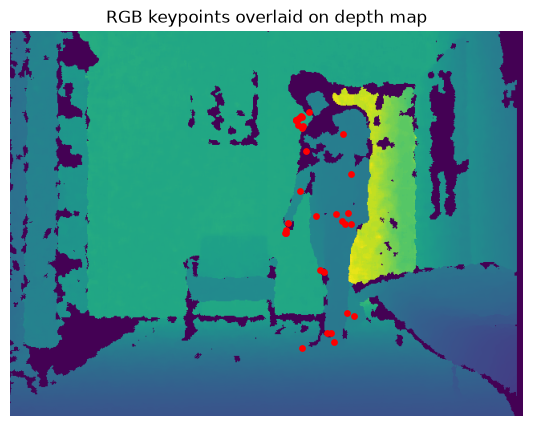

In [ ]:
# --- Alignment check: do the RGB keypoints land on the person in the DEPTH map? ---

H, W = depth_mm.shape # depth image size (rows, cols) = (480, 640)

# Re-detect pose on frame 0's RGB image to get its keypoints
img0 = cv2.cvtColor(cv2.imread(frame_paths[75]), cv2.COLOR_BGR2RGB)
with mp_pose.Pose(static_image_mode=True, model_complexity=2) as pose:
    res0 = pose.process(img0)

lm0 = res0.pose_landmarks.landmark

# Convert normalized (0-1) landmark coords to pixel positions
xs = [p.x * W for p in lm0]
ys = [p.y * H for p in lm0]

# Show the depth map with the RGB keypoints drawn on top
plt.figure(figsize=(7, 5))
plt.imshow(depth_mm, cmap="viridis")
plt.scatter(xs, ys, c="red", s=15) # RGB keypoints, in red
plt.title("RGB keypoints overlaid on depth map")
plt.axis("off")
plt.show()

In [ ]:
# --- Read depth at the leg keypoints and check that values make sense ---

for name, idx in [("hip", HIP), ("knee", KNEE), ("ankle", ANKLE)]:
    u = int(round(lm0[idx].x * W)) # pixel column
    v = int(round(lm0[idx].y * H)) # pixel row
    d = depth_mm[v, u] # depth at that pixel (note: [row, col] = [v, u])
    print(f"{name:5s}  pixel=({u:3d},{v:3d})  depth={d:.0f} mm")

hip    pixel=(406,228)  depth=2869 mm
knee   pixel=(391,300)  depth=0 mm
ankle  pixel=(394,376)  depth=0 mm


In [ ]:
# --- Robust depth lookup to address the 0-depth holes: sample median of valid pixels in a small patch ---

def depth_at(depth_map, u, v, k=2):
    """Median depth in a (2k+1)x(2k+1) window around (u,v), ignoring 0s (invalid)."""
    H, W = depth_map.shape
    u0, u1 = max(0, u-k), min(W, u+k+1)
    v0, v1 = max(0, v-k), min(H, v+k+1)
    patch = depth_map[v0:v1, u0:u1] # small window
    valid = patch[patch > 0] # drop the no-measurement 0s
    return np.median(valid) if valid.size else np.nan # NaN if the whole patch is empty

# retest the three joints with the patch method
for name, idx in [("hip", HIP), ("knee", KNEE), ("ankle", ANKLE)]:
    u = int(round(lm0[idx].x * W))
    v = int(round(lm0[idx].y * H))
    d = depth_at(depth_mm, u, v, k=3) # 7x7 window
    print(f"{name:5s}  pixel=({u:3d},{v:3d})  depth={d:.0f} mm" if not np.isnan(d)
          else f"{name:5s}  pixel=({u:3d},{v:3d})  depth=NaN (all invalid)")

hip    pixel=(406,228)  depth=2869 mm
knee   pixel=(391,300)  depth=3101 mm
ankle  pixel=(394,376)  depth=2777 mm


In [ ]:
# --- Camera intrinsics for the Kinect v1 depth sensor (from Kwolek & Kepski 2014) ---
# These describe how the lens maps 3D points onto the 640x480 pixel grid.

fx = 580.0 # focal length in pixels (x) — from the paper
fy = 580.0 # focal length in pixels (y) — same sensor
cx = 320.0 # optical center x = image width  / 2  (640/2)
cy = 240.0 # optical center y = image height / 2  (480/2)

print(f"intrinsics set: fx={fx}, fy={fy}, cx={cx}, cy={cy}")

intrinsics set: fx=580.0, fy=580.0, cx=320.0, cy=240.0


In [ ]:
# --- Back-project a pixel + depth into a metric 3D point (X, Y, Z) in mm ---

def backproject(u, v, d):
    """Pixel (u,v) at depth d (mm) -> 3D point (X, Y, Z) in mm, camera at origin."""
    Z = d
    X = (u - cx) * d / fx
    Y = (v - cy) * d / fy
    return np.array([X, Y, Z])

# Build a 3D point for each leg joint on frame 75
points_3d = {}
for name, idx in [("hip", HIP), ("knee", KNEE), ("ankle", ANKLE)]:
    u = int(round(lm0[idx].x * W))
    v = int(round(lm0[idx].y * H))
    d = depth_at(depth_mm, u, v, k=3) # robust patch lookup
    points_3d[name] = backproject(u, v, d)
    print(f"{name:5s} -> X={points_3d[name][0]:7.1f}  Y={points_3d[name][1]:7.1f}  Z={points_3d[name][2]:7.1f} mm")

hip   -> X=  425.4  Y=  -59.4  Z= 2869.0 mm
knee  -> X=  379.6  Y=  320.8  Z= 3101.0 mm
ankle -> X=  354.3  Y=  651.2  Z= 2777.0 mm


In [62]:
# --- 3D knee angle from the back-projected points from depth data ---

knee_angle_3d = joint_angle(points_3d["hip"], points_3d["knee"], points_3d["ankle"])
print(f"knee angle (depth 3D): {knee_angle_3d:.1f}°")

knee angle (depth 3D): 104.4°


In [63]:
# --- Fair 2D-vs-3D comparison for a single frame, with depth reliability info ---
C = 7000

def angles_for_frame(i, k=3):
    rgb = cv2.cvtColor(cv2.imread(frame_paths[i]), cv2.COLOR_BGR2RGB)
    raw = cv2.imread(depth_paths[i], cv2.IMREAD_UNCHANGED)
    dmm = C * raw.astype(np.float32) / 65535.0
    H, W = dmm.shape

    with mp_pose.Pose(static_image_mode=True, model_complexity=2) as pose:
        res = pose.process(rgb)
    if not res.pose_landmarks:
        return None
    lm = res.pose_landmarks.landmark

    # 2D angle in PIXELS (fair — matches the depth arm's real units)
    def px(idx): return np.array([lm[idx].x * W, lm[idx].y * H])
    a2d = joint_angle(px(HIP), px(KNEE), px(ANKLE))

    # 3D angle + the depth used at each joint
    def p3(idx):
        u = int(round(lm[idx].x * W)); v = int(round(lm[idx].y * H))
        d = depth_at(dmm, u, v, k=k)
        return backproject(u, v, d), d
    P_hip, d_hip   = p3(HIP)
    P_knee, d_knee = p3(KNEE)
    P_ank,  d_ank  = p3(ANKLE)
    a3d = joint_angle(P_hip, P_knee, P_ank)

    print(f"frame {i}:  2D(pixels) = {a2d:6.1f}°   3D(depth) = {a3d:6.1f}°   diff = {a2d-a3d:+.1f}°")
    print(f"           joint depths (mm):  hip={d_hip:.0f}  knee={d_knee:.0f}  ankle={d_ank:.0f}")

angles_for_frame(0)
angles_for_frame(75)

I0000 00:00:1782949079.969897 37969676 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4 Pro
W0000 00:00:1782949080.059115 38855382 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1782949080.108337 38855394 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1782949080.144504 37969676 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4 Pro


frame 75:  2D(pixels) =  165.9°   3D(depth) =  104.4°   diff = +61.5°
           joint depths (mm):  hip=2869  knee=3101  ankle=2777


W0000 00:00:1782949080.214487 38855404 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1782949080.248756 38855407 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [64]:
def depth_quality(i, k=3):
    raw = cv2.imread(depth_paths[i], cv2.IMREAD_UNCHANGED)
    dmm = C * raw.astype(np.float32) / 65535.0
    H, W = dmm.shape
    rgb = cv2.cvtColor(cv2.imread(frame_paths[i]), cv2.COLOR_BGR2RGB)
    with mp_pose.Pose(static_image_mode=True, model_complexity=2) as pose:
        res = pose.process(rgb)
    lm = res.pose_landmarks.landmark
    for name, idx in [("hip", HIP), ("knee", KNEE), ("ankle", ANKLE)]:
        u = int(round(lm[idx].x * W)); v = int(round(lm[idx].y * H))
        patch = dmm[max(0,v-k):v+k+1, max(0,u-k):u+k+1]
        valid = patch[patch > 0]
        center = dmm[v, u]
        print(f"{name:5s} (u={u},v={v})  center_pixel={center:.0f}mm  "
              f"valid_in_patch={valid.size}/{patch.size}")

depth_quality(75)

I0000 00:00:1783023869.402557 37969676 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4 Pro
W0000 00:00:1783023869.505450 39033690 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1783023869.556076 39033702 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


hip   (u=406,v=228)  center_pixel=2869mm  valid_in_patch=49/49
knee  (u=391,v=300)  center_pixel=0mm  valid_in_patch=6/49
ankle (u=394,v=376)  center_pixel=0mm  valid_in_patch=13/49


In [ ]:
# --- Depth lookup with a quality gate: return NaN if too few valid pixels ---

def depth_at_gated(depth_map, u, v, k=3, min_valid_frac=0.5):
    """Median depth in a (2k+1)^2 window, but only if at least `min_valid_frac`
    of the pixels are real measurements. Otherwise NaN (untrustworthy)."""
    H, W = depth_map.shape
    # 1. Grab a small square patch of pixels around the joint (u,v).
    # k=3 means a 7x7 window (3 pixels out in every direction).
    patch = depth_map[max(0,v-k):v+k+1, max(0,u-k):u+k+1]
    # 2. Keep only the pixels that have a REAL measurement (value > 0).
    # The zeros are the "I don't know" holes — throw them out.
    valid = patch[patch > 0]
    if valid.size < min_valid_frac * patch.size:   # too holey -> don't trust it
        return np.nan
    return np.median(valid)

# retest frame 75's joints with the gate
raw = cv2.imread(depth_paths[75], cv2.IMREAD_UNCHANGED)
dmm = C * raw.astype(np.float32) / 65535.0
rgb = cv2.cvtColor(cv2.imread(frame_paths[75]), cv2.COLOR_BGR2RGB)
with mp_pose.Pose(static_image_mode=True, model_complexity=2) as pose:
    lm = pose.process(rgb).pose_landmarks.landmark

H, W = dmm.shape
for name, idx in [("hip", HIP), ("knee", KNEE), ("ankle", ANKLE)]:
    u = int(round(lm[idx].x * W)); v = int(round(lm[idx].y * H))
    d = depth_at_gated(dmm, u, v)
    print(f"{name:5s}: depth = {'NaN (rejected)' if np.isnan(d) else f'{d:.0f} mm'}")

I0000 00:00:1783024475.402966 37969676 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4 Pro
W0000 00:00:1783024475.478854 39043032 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1783024475.532989 39043033 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


hip  : depth = 2869 mm
knee : depth = NaN (rejected)
ankle: depth = NaN (rejected)


In [66]:
# --- How often can depth reliably reconstruct all 3 leg joints? ---

def depth_3d_knee_angle(i, k=3, min_valid_frac=0.5):
    raw = cv2.imread(depth_paths[i], cv2.IMREAD_UNCHANGED)
    dmm = C * raw.astype(np.float32) / 65535.0
    rgb = cv2.cvtColor(cv2.imread(frame_paths[i]), cv2.COLOR_BGR2RGB)
    with mp_pose.Pose(static_image_mode=False, model_complexity=2) as pose:
        res = pose.process(rgb)
    if not res.pose_landmarks:
        return np.nan
    lm = res.pose_landmarks.landmark
    H, W = dmm.shape
    pts = {}
    for name, idx in [("hip", HIP), ("knee", KNEE), ("ankle", ANKLE)]:
        u = int(round(lm[idx].x * W)); v = int(round(lm[idx].y * H))
        d = depth_at_gated(dmm, u, v, k, min_valid_frac)
        if np.isnan(d):
            return np.nan          # any joint unreliable -> no 3D angle this frame
        pts[name] = backproject(u, v, d)
    return joint_angle(pts["hip"], pts["knee"], pts["ankle"])

knee_3d = np.array([depth_3d_knee_angle(i) for i in range(len(frame_paths))])

n_valid = np.sum(~np.isnan(knee_3d))
print(f"depth 3D knee angle available in {n_valid}/{len(frame_paths)} frames "
      f"({100*n_valid/len(frame_paths):.0f}%)")

I0000 00:00:1783024697.478046 37969676 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4 Pro
W0000 00:00:1783024697.553189 39046909 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1783024697.602270 39046915 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1783024697.633416 37969676 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4 Pro
W0000 00:00:1783024697.703110 39046929 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1783024697.739207 39046937 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1783024697.769928 3796

depth 3D knee angle available in 91/150 frames (61%)


W0000 00:00:1783024728.247093 39049417 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1783024728.281216 39049417 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [67]:
# --- Compare RGB (2D, pixels) vs depth (3D) knee angle, on frames where both are valid ---

# 2D pixel-based knee angle across all frames (the fair version)
def rgb_2d_knee_angle(i):
    rgb = cv2.cvtColor(cv2.imread(frame_paths[i]), cv2.COLOR_BGR2RGB)
    with mp_pose.Pose(static_image_mode=False, model_complexity=2) as pose:
        res = pose.process(rgb)
    if not res.pose_landmarks:
        return np.nan
    lm = res.pose_landmarks.landmark
    H, W = 480, 640
    def px(idx): return np.array([lm[idx].x * W, lm[idx].y * H])
    return joint_angle(px(HIP), px(KNEE), px(ANKLE))

knee_2d = np.array([rgb_2d_knee_angle(i) for i in range(len(frame_paths))])

# keep only frames where BOTH arms produced a value
both = ~np.isnan(knee_2d) & ~np.isnan(knee_3d)
print(f"both valid in {both.sum()} frames")

diff = knee_2d[both] - knee_3d[both]
print(f"mean difference (2D - 3D): {np.mean(diff):+.1f}°")
print(f"RMSE:                      {np.sqrt(np.mean(diff**2)):.1f}°")
print(f"correlation:               {np.corrcoef(knee_2d[both], knee_3d[both])[0,1]:.3f}")

I0000 00:00:1783026742.972820 37969676 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4 Pro
W0000 00:00:1783026743.044548 39073613 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1783026743.100023 39073623 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1783026743.124822 37969676 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4 Pro
W0000 00:00:1783026743.189694 39073625 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1783026743.226782 39073630 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1783026743.253698 3796

both valid in 91 frames
mean difference (2D - 3D): +5.0°
RMSE:                      32.3°
correlation:               0.819


W0000 00:00:1783026772.759663 39076110 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1783026772.792402 39076123 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


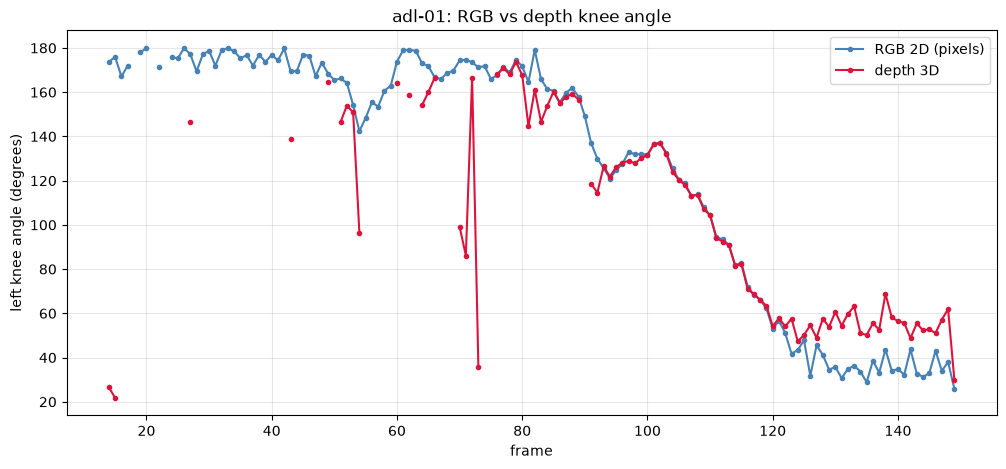

In [68]:
# --- Plot RGB (2D) vs depth (3D) knee angle over time ---

plt.figure(figsize=(12, 5))
plt.plot(knee_2d, color="steelblue", marker=".", label="RGB 2D (pixels)")
plt.plot(knee_3d, color="crimson",  marker=".", label="depth 3D")
plt.xlabel("frame")
plt.ylabel("left knee angle (degrees)")
plt.title("adl-01: RGB vs depth knee angle")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [69]:
# --- How much do the outlier frames distort the metrics? ---

# robust alternative to RMSE: median absolute difference (outlier-resistant)
median_abs = np.median(np.abs(diff))
print(f"median |2D - 3D|: {median_abs:.1f}°   (vs RMSE {np.sqrt(np.mean(diff**2)):.1f}°)")

# how many frames disagree by more than 25 degrees?
big = np.abs(diff) > 25
print(f"frames disagreeing >25 deg: {big.sum()} / {both.sum()}")

# metrics after dropping those extreme disagreements
keep = np.abs(diff) <= 25
print(f"\nafter removing large disagreements ({keep.sum()} frames):")
print(f"  mean diff: {np.mean(diff[keep]):+.1f}°")
print(f"  RMSE:      {np.sqrt(np.mean(diff[keep]**2)):.1f}°")
print(f"  correlation: {np.corrcoef(knee_2d[both][keep], knee_3d[both][keep])[0,1]:.3f}")

median |2D - 3D|: 4.1°   (vs RMSE 32.3°)
frames disagreeing >25 deg: 10 / 91

after removing large disagreements (81 frames):
  mean diff: -2.5°
  RMSE:      12.3°
  correlation: 0.988
